In [1]:
import numpy as np
import sys
from pathlib import Path
import copy
from time import time

Base_Dir = './' # assuming we are in zeldovich-smearing/emulation/, else modify this
Code_Dir = Base_Dir + '../code/'
sys.path.append(Code_Dir)

from emulation import AgnosticEmulator

In [2]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import matplotlib as mpl
import matplotlib.colors as pltcol

mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['legend.fontsize'] = 14
mpl.rcParams['legend.labelspacing'] = 0.25

FS = 18
FS2 = 15
FS3 = 13
FSL = 22

mpl.rcParams['xtick.major.size'] = 6
mpl.rcParams['xtick.minor.size'] = 3
mpl.rcParams['ytick.major.size'] = 6
mpl.rcParams['ytick.minor.size'] = 3
print('mpl setup done')
#mpl.rcParams.keys()

mpl setup done


***
# Agnostic $\leftrightarrow$ Cosmological Emulation
### Build forward and inverse emulators for model-agnostic BAO inference
***

## Common setup variables

### Emulation [NUCDM SAMPLES TO BE RUN AGAIN]

In [3]:
Cosmo = 'wcdm'  # one of ['lcdm','wcdm','nucdm','w0wacdm']
Flat = False    # whether or not to vary spatial curvature

# control which emulators to operate on
# -- operate: bool, whether or not to initialize emulators 
# --   build: bool, True - build from scratch, False - load existing NEO.
# **************
# Once an emulator is built and finalized, set its 'build' value to False to avoid overwriting
# **************
Run_Default = {'operate':False,'build':False}
Run_Deep = {'operate':False,'build':False}
Run_Shallow = {'operate':True,'build':True}
Run_Telescopic = {'operate':False,'build':False}


Z_Eval = 0.8
Scale_Planck18 = 6.0

In [4]:
Out_Stem = 'emulators/'

setup = {'out_stem':Out_Stem,
         'cosmo':Cosmo,
         'flat':Flat,
         'z_eval':Z_Eval,
         'scale_planck18':Scale_Planck18,
         # 'rmin':30.0,'rmax':150.0,
         # 'n_r':60,
         # 'mnu_max':0.3,
         # 'kmin':0.02,'kmax':0.05,
         # 'high_acc':True,
         'verbose':True,'logfile':None
         }

print(setup)

{'out_stem': 'emulators/', 'cosmo': 'wcdm', 'flat': False, 'z_eval': 0.8, 'scale_planck18': 6.0, 'verbose': True, 'logfile': None}


### Samples

In [5]:
Save_Xi = True # only used for test sample. Set True if stringent test for basis set is needed in Use_Emulators.ipynb

# manipulate these as needed to overwrite training/test samples
Force_Train = False
Force_Test  = False

SampleDict = {'train':{'sample_stem':'train','seed':1983,'include_fiducial':False,'save_xi':False,'force':Force_Train,
                       'n_samp':3000#//3 #for lcdm_flat
                      },
               'test':{'sample_stem':'test', 'seed':1991,'include_fiducial':True,'save_xi':Save_Xi,'force':Force_Test,
                       'n_samp':-1+2000
                      }}

## `AgnosticEmulator` setup

In [6]:
agem = AgnosticEmulator(setup=setup)

print('Parameter variations...')
for p in range(len(agem.keys_vary)):
    print('... '+agem.keys_vary[p]+': [{0:.3e},{1:.3e}]'.format(agem.param_mins[p],agem.param_maxs[p]))
print('---------------')

Agnostic emulator for BAO inference...
... will work in folder: emulators/scale6.0/z0.80/
... extracting basis functions as NN
... done
... evaluating 9 basis functions
... done
... setting up fiducial cosmology and sampling ranges
... setting up parameter variations for family: wcdm
... fiducial params:
... ... Om: 3.1530e-01
... ... h: 6.7370e-01
... ... As: 2.1010e-09
... ... ns: 9.6490e-01
... ... Ob: 4.9287e-02
... ... Ok: 0.0000e+00
... ... wDE0: -1.0000e+00
... setup complete
0 min 3.30 seconds

Parameter variations...
... Om: [2.715e-01,3.591e-01]
... h: [6.413e-01,7.061e-01]
... As: [1.925e-09,2.277e-09]
... ns: [9.397e-01,9.901e-01]
... Ob: [4.415e-02,5.443e-02]
... Ok: [-7.500e-02,7.500e-02]
... wDE0: [-1.600e+00,-4.000e-01]
---------------


## Samples

### Training sample

In [7]:
sset_train = {}
for key in SampleDict['train'].keys():
    sset_train[key] = SampleDict['train'][key]

agnostic,cosmological = agem.gen_sample(sample_setup=sset_train)

Generating/reading sample from: emulators/scale6.0/z0.80/wcdm/samples/train
... folder exists, attempting to read
... read 2997 samples
0 min 0.00 seconds



### Testing sample

In [8]:
sset_test = {}
for key in SampleDict['test'].keys():
    sset_test[key] = SampleDict['test'][key]

out = agem.gen_sample(sample_setup=sset_test)
if sset_test['save_xi']:
    agnostic_test,cosmological_test,xilin = out
else:
    agnostic_test,cosmological_test = out
    xilin = None

Generating/reading sample from: emulators/scale6.0/z0.80/wcdm/samples/test
... folder exists, attempting to read
... read 1997 samples
0 min 0.02 seconds



agnostic.shape: (13, 1997) ; expected: (13,2000)
cosmological.shape: (7, 1997) ; expected: (7,2000)
xilin.shape: (1997, 60) ; expected: (2000,60)


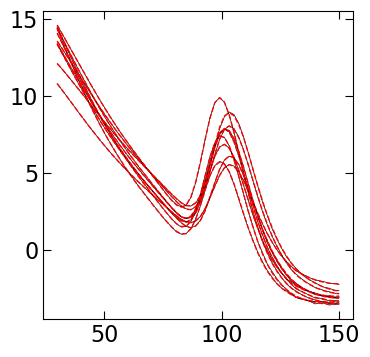

In [9]:
n_samp_exp = sset_test['n_samp']+int(sset_test['include_fiducial'])
print('agnostic.shape:',agnostic_test.shape,'; expected: ({0:d},{1:d})'.format(agem.n_agnostic,n_samp_exp))
print('cosmological.shape:',cosmological_test.shape,'; expected: ({0:d},{1:d})'.format(agem.n_params,n_samp_exp))

if sset_test['save_xi'] & (xilin is not None):
    print('xilin.shape:',xilin.shape,'; expected: ({0:d},{1:d})'.format(n_samp_exp,agem.n_r))
    predicted_xilin = np.dot(agem.basis_func.T,agnostic_test[:agem.n_basis]).T
    plt.figure(figsize=(4,4))
    for n in range(np.min([10,n_samp_exp])):
        plt.plot(agem.rvals,agem.rvals**2*xilin[n],'k-',lw=0.5)
        plt.plot(agem.rvals,agem.rvals**2*predicted_xilin[n],'r--',lw=1)
    plt.show()

## Emulators

In [10]:
setup_hopt = {'max_epoch':15000,  # was 5000 for lcdm_flat
              'check_after':7000, # was 5000 for lcdm_flat
              'n_iter':3,
              'max_config':150,   # was 100  for lcdm_flat
              'ensemble_size':10,
              'train_frac':0.9,'val_frac':0.1,
              'nproc':12,
              'family':'seq',
              'wt_decays':{'min':0.0,'max':0.1},
              'htypes':['tanh','splus','relu','sin'], # may be changed below
              'fixed_width':False, # will be None for telescopic
              'fixed_htype':False}

### Default model

In [11]:
setup_default = copy.deepcopy(setup_hopt)
setup_default['model_name'] = 'default'
setup_default['layers'] = {'min':2,'max':5}
setup_default['widths'] = {'min':5,'max':45}
setup_default['lglrates'] = {'min':-3.0,'max':-2.0}

#### Forward

In [12]:
if Run_Default['operate']:
    start_time = time()
    neo_def_fwd = agem.emulate(agnostic,cosmological,invert=False,setup_hopt=setup_default,optimize=Run_Default['build'])
    agem.time_this(start_time)
    neo_def_fwd.display_summary()

#### Inverse

In [13]:
if Run_Default['operate']:
    start_time = time()
    neo_def_inv = agem.emulate(agnostic,cosmological,invert=True,setup_hopt=setup_default,optimize=Run_Default['build'])
    agem.time_this(start_time)
    neo_def_inv.display_summary()

### Deep

In [14]:
setup_deep = copy.deepcopy(setup_hopt)
setup_deep['model_name'] = 'deep'
setup_deep['layers'] = {'min':10,'max':20}
setup_deep['widths'] = {'min':5,'max':10}
setup_deep['lglrates'] = {'min':-4.0,'max':-2.0}

#### Forward

In [15]:
if Run_Deep['operate']:
    start_time = time()
    neo_deep_fwd = agem.emulate(agnostic,cosmological,invert=False,setup_hopt=setup_deep,optimize=Run_Deep['build'])
    agem.time_this(start_time)
    neo_deep_fwd.display_summary()

#### Inverse

In [16]:
if Run_Deep['operate']:
    start_time = time()
    neo_deep_inv = agem.emulate(agnostic,cosmological,invert=True,setup_hopt=setup_deep,optimize=Run_Deep['build'])
    agem.time_this(start_time)
    neo_deep_inv.display_summary()

### Shallow

In [17]:
setup_shallow = copy.deepcopy(setup_hopt)
setup_shallow['model_name'] = 'shallow'
setup_shallow['layers'] = {'min':2,'max':4}
setup_shallow['widths'] = {'min':50,'max':250}
setup_shallow['lglrates'] = {'min':-4.5,'max':-2.5}

#### Forward

Emulating forward mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... standard training will be implemented
... found data set of dimension 7 with targets of dimension 13
... found 2997 samples
... fraction 0.900 (2697 samples) will be used for training
... will search over 3 iterations of 150 configurations
... will store best 10 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 12 process(es)
[................... ] 100% done
[................... ] 95% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
626 min 35.34 seconds

Best test stats:
... emulators/scale6.0

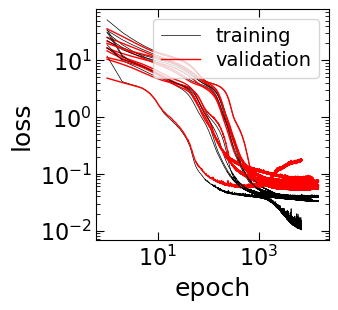

In [18]:
if Run_Shallow['operate']:
    start_time = time()
    neo_shal_fwd = agem.emulate(agnostic,cosmological,invert=False,setup_hopt=setup_shallow,optimize=Run_Shallow['build'])
    agem.time_this(start_time)
    neo_shal_fwd.display_summary()

#### Inverse

Emulating inverse mapping...
--------------
Hyperparameter + architecture optimization
--------------
... neural network family: Sequential
... ... standard training will be implemented
... found data set of dimension 13 with targets of dimension 7
... found 2997 samples
... fraction 0.900 (2697 samples) will be used for training
... will search over 3 iterations of 150 configurations
... will store best 10 networks in ensemble
... will use residual percentiles for hyperparameter comparison
... weight decays will use norm 2
... setup complete
Initiating search... 
... setting tasks
... training using 12 process(es)
[................... ] 100% done
[................... ] 99% done... defining and loading NetworkEnsembleObject
NetworkEnsembleObject initialized
... ... initializing dict self.ensemble
... ... updating ensemble
... ... checking ensemble consistency
... ... defining ensemble weights
... ensemble loaded and checked
644 min 2.31 seconds

Best test stats:
... emulators/scale6.0/

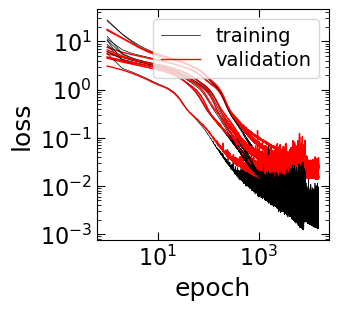

In [19]:
if Run_Shallow['operate']:
    start_time = time()
    neo_shal_inv = agem.emulate(agnostic,cosmological,invert=True,setup_hopt=setup_shallow,optimize=Run_Shallow['build'])
    agem.time_this(start_time)
    neo_shal_inv.display_summary()

### Telescopic

In [20]:
setup_telescopic = copy.deepcopy(setup_hopt)
setup_telescopic['model_name'] = 'telescopic'
setup_telescopic['layers'] = {'min':5,'max':10}
setup_telescopic['widths'] = {'min':50,'max':200}
setup_telescopic['lglrates'] = {'min':-4.5,'max':-3.0}
setup_telescopic['fixed_width'] = None

#### Forward

In [21]:
if Run_Telescopic['operate']:
    start_time = time()
    neo_tele_fwd = agem.emulate(agnostic,cosmological,invert=False,setup_hopt=setup_telescopic,optimize=Run_Telescopic['build'])
    agem.time_this(start_time)
    neo_tele_fwd.display_summary()

#### Inverse

In [22]:
if Run_Telescopic['operate']:
    start_time = time()
    neo_tele_inv = agem.emulate(agnostic,cosmological,invert=True,setup_hopt=setup_telescopic,optimize=Run_Telescopic['build'])
    agem.time_this(start_time)
    neo_tele_inv.display_summary()

## Model performance

In [23]:
Save_Fig = True

bins = np.linspace(-1,1,800)
bin_mid = 0.5*(bins[1:]+bins[:-1])
dx = bins[1]-bins[0]

In [24]:
start_time = time()
print('Predictions...')
if Run_Default['operate']:
    agnostic_predict_def = neo_def_fwd.predict(cosmological_test)
    cosmological_predict_def = neo_def_inv.predict(agnostic_test)

if Run_Deep['operate']:
    agnostic_predict_deep = neo_deep_fwd.predict(cosmological_test)
    cosmological_predict_deep = neo_deep_inv.predict(agnostic_test)

if Run_Shallow['operate']:
    agnostic_predict_shal = neo_shal_fwd.predict(cosmological_test)
    cosmological_predict_shal = neo_shal_inv.predict(agnostic_test)

if Run_Telescopic['operate']:
    agnostic_predict_tele = neo_tele_fwd.predict(cosmological_test)
    cosmological_predict_tele = neo_tele_inv.predict(agnostic_test)
agem.time_this(start_time)

Predictions...
0 min 0.27 seconds



Flattened residuals...
Saving to file: emulators/scale6.0/z0.80/wcdm/plots/emulator_residuals.pdf


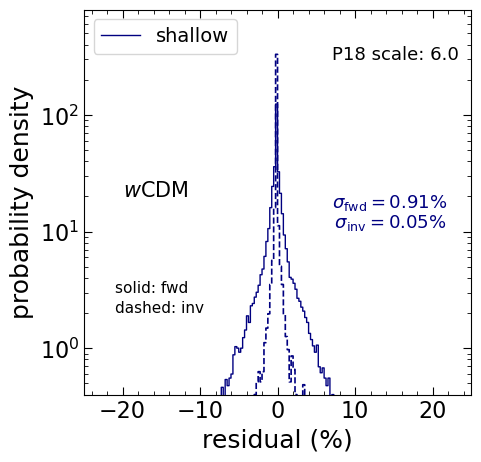

In [25]:
print('Flattened residuals...')
###########################
if Run_Default['operate']:
    err_agnos_def = (agnostic_predict_def/(agnostic_test + 1e-15) - 1).flatten()
    err_agnos_def = err_agnos_def[np.isfinite(err_agnos_def)]
    errwidth_agnos_def = 0.5*(np.percentile(err_agnos_def,84)-np.percentile(err_agnos_def,16))
    
    err_cosmo_def = (cosmological_predict_def/(cosmological_test + 1e-15) - 1).flatten()
    err_cosmo_def = err_cosmo_def[np.isfinite(err_cosmo_def)]
    errwidth_cosmo_def = 0.5*(np.percentile(err_cosmo_def,84)-np.percentile(err_cosmo_def,16))
    
    hist_agnos_def,dummy = np.histogram(err_agnos_def,bins=bins,density=False)
    hist_agnos_def = hist_agnos_def/err_agnos_def.size/dx
    hist_cosmo_def,dummy = np.histogram(err_cosmo_def,bins=bins,density=False)
    hist_cosmo_def = hist_cosmo_def/err_cosmo_def.size/dx
###########################
if Run_Deep['operate']:
    err_agnos_deep = (agnostic_predict_deep/(agnostic_test + 1e-15) - 1).flatten()
    err_agnos_deep = err_agnos_deep[np.isfinite(err_agnos_deep)]
    errwidth_agnos_deep = 0.5*(np.percentile(err_agnos_deep,84)-np.percentile(err_agnos_deep,16))
    
    err_cosmo_deep = (cosmological_predict_deep/(cosmological_test + 1e-15) - 1).flatten()
    err_cosmo_deep = err_cosmo_deep[np.isfinite(err_cosmo_deep)]
    errwidth_cosmo_deep = 0.5*(np.percentile(err_cosmo_deep,84)-np.percentile(err_cosmo_deep,16))

    hist_agnos_deep,dummy = np.histogram(err_agnos_deep,bins=bins,density=False)
    hist_agnos_deep = hist_agnos_deep/err_agnos_deep.size/dx
    hist_cosmo_deep,dummy = np.histogram(err_cosmo_deep,bins=bins,density=False)
    hist_cosmo_deep = hist_cosmo_deep/err_cosmo_deep.size/dx
###########################
if Run_Shallow['operate']:
    err_agnos_shal = (agnostic_predict_shal/(agnostic_test + 1e-15) - 1).flatten()
    err_agnos_shal = err_agnos_shal[np.isfinite(err_agnos_shal)]
    errwidth_agnos_shal = 0.5*(np.percentile(err_agnos_shal,84)-np.percentile(err_agnos_shal,16))
    
    err_cosmo_shal = (cosmological_predict_shal/(cosmological_test + 1e-15) - 1).flatten()
    err_cosmo_shal = err_cosmo_shal[np.isfinite(err_cosmo_shal)]
    errwidth_cosmo_shal = 0.5*(np.percentile(err_cosmo_shal,84)-np.percentile(err_cosmo_shal,16))

    hist_agnos_shal,dummy = np.histogram(err_agnos_shal,bins=bins,density=False)
    hist_agnos_shal = hist_agnos_shal/err_agnos_shal.size/dx
    hist_cosmo_shal,dummy = np.histogram(err_cosmo_shal,bins=bins,density=False)
    hist_cosmo_shal = hist_cosmo_shal/err_cosmo_shal.size/dx
###########################
if Run_Telescopic['operate']:
    err_agnos_tele = (agnostic_predict_tele/(agnostic_test + 1e-15) - 1).flatten()
    err_agnos_tele = err_agnos_tele[np.isfinite(err_agnos_tele)]
    errwidth_agnos_tele = 0.5*(np.percentile(err_agnos_tele,84)-np.percentile(err_agnos_tele,16))
    
    err_cosmo_tele = (cosmological_predict_tele/(cosmological_test + 1e-15) - 1).flatten()
    err_cosmo_tele = err_cosmo_tele[np.isfinite(err_cosmo_tele)]
    errwidth_cosmo_tele = 0.5*(np.percentile(err_cosmo_tele,84)-np.percentile(err_cosmo_tele,16))

    hist_agnos_tele,dummy = np.histogram(err_agnos_tele,bins=bins,density=False)
    hist_agnos_tele = hist_agnos_tele/err_agnos_tele.size/dx
    hist_cosmo_tele,dummy = np.histogram(err_cosmo_tele,bins=bins,density=False)
    hist_cosmo_tele = hist_cosmo_tele/err_cosmo_tele.size/dx
###########################

FSize = 5
plt.figure(figsize=(FSize,FSize))
plt.yscale('log')
plt.xlim(-25,25)
plt.ylim(4e-1,8e2)
plt.xlabel('residual (%)')
plt.ylabel('probability density')
Xt,Yf,Yi = 7,40,27
if Run_Default['operate']:
    plt.plot(bin_mid*100,hist_agnos_def,ls='-',c='darkgoldenrod',drawstyle='steps',lw=1,label='default')
    plt.plot(bin_mid*100,hist_cosmo_def,ls='--',c='darkgoldenrod',drawstyle='steps',lw=1.2)
    plt.text(Xt,Yf*2.5,'$\\sigma_{{\\rm fwd}} = {0:.2f}\%$'.format(100*errwidth_agnos_def),fontsize=FS3,c='darkgoldenrod')
    plt.text(Xt,Yi*2.5,'$\\,\\sigma_{{\\rm inv}} = {0:.2f}\%$'.format(100*errwidth_cosmo_def),fontsize=FS3,c='darkgoldenrod')
if Run_Deep['operate']:
    plt.plot(bin_mid*100,hist_agnos_deep,ls='-',c='forestgreen',drawstyle='steps',lw=1,label='deep')
    plt.plot(bin_mid*100,hist_cosmo_deep,ls='--',c='forestgreen',drawstyle='steps',lw=1.2)
    plt.text(Xt,Yf,'$\\sigma_{{\\rm fwd}} = {0:.2f}\%$'.format(100*errwidth_agnos_deep),fontsize=FS3,c='forestgreen')
    plt.text(Xt,Yi,'$\\,\\sigma_{{\\rm inv}} = {0:.2f}\%$'.format(100*errwidth_cosmo_deep),fontsize=FS3,c='forestgreen')
if Run_Shallow['operate']:
    plt.plot(bin_mid*100,hist_agnos_shal,ls='-',c='navy',drawstyle='steps',lw=1,label='shallow')
    plt.plot(bin_mid*100,hist_cosmo_shal,ls='--',c='navy',drawstyle='steps',lw=1.2)
    plt.text(Xt,Yf/2.5,'$\\sigma_{{\\rm fwd}} = {0:.2f}\%$'.format(100*errwidth_agnos_shal),fontsize=FS3,c='navy')
    plt.text(Xt,Yi/2.5,'$\\,\\sigma_{{\\rm inv}} = {0:.2f}\%$'.format(100*errwidth_cosmo_shal),fontsize=FS3,c='navy')
if Run_Telescopic['operate']:
    plt.plot(bin_mid*100,hist_agnos_tele,ls='-',c='crimson',drawstyle='steps',lw=1,label='telescopic')
    plt.plot(bin_mid*100,hist_cosmo_tele,ls='--',c='crimson',drawstyle='steps',lw=1.2)
    plt.text(Xt,Yf/2.5**2,'$\\sigma_{{\\rm fwd}} = {0:.2f}\%$'.format(100*errwidth_agnos_tele),fontsize=FS3,c='crimson')
    plt.text(Xt,Yi/2.5**2,'$\\,\\sigma_{{\\rm inv}} = {0:.2f}\%$'.format(100*errwidth_cosmo_tele),fontsize=FS3,c='crimson')
plt.legend(loc='upper left')
plt.text(-20,20,agem.cosmo_latex,fontsize=FS2)
plt.text(Xt,3e2,'P18 scale: {0:.1f}'.format(agem.scale_planck18),fontsize=FS3)
plt.text(-21,3,'solid: fwd',fontsize=11)
plt.text(-21,2,'dashed: inv',fontsize=11)
plt.minorticks_on()
if Save_Fig:
    outfile = agem.plot_dir + 'emulator_residuals.pdf'
    print('Saving to file:',outfile)
    plt.savefig(outfile,bbox_inches='tight')
else:
    plt.show()

In [26]:
print('Parameter-wise residuals...')
###########################
if Run_Default['operate']:
    err_agnos_def = (agnostic_predict_def/(agnostic_test + 1e-15) - 1)
    errwidth_agnos_def = 0.5*(np.percentile(err_agnos_def,84,axis=1)-np.percentile(err_agnos_def,16,axis=1))
    err_cosmo_def = (cosmological_predict_def/(cosmological_test + 1e-15) - 1)
    errwidth_cosmo_def = 0.5*(np.percentile(err_cosmo_def,84,axis=1)-np.percentile(err_cosmo_def,16,axis=1))
    print('--------')
    print('... default')
    print('--------')
    print('... ... forward')
    for p in range(len(agem.keys_agnostic)):
        print(agem.keys_agnostic[p]+': {0:.3e}'.format(errwidth_agnos_def[p]))
    print('--------')
    print('... ... inverse')
    for p in range(len(agem.keys_vary)):
        print(agem.keys_vary[p]+': {0:.3e}'.format(errwidth_cosmo_def[p]))
###########################
if Run_Deep['operate']:
    err_agnos_deep = (agnostic_predict_deep/(agnostic_test + 1e-15) - 1)
    errwidth_agnos_deep = 0.5*(np.percentile(err_agnos_deep,84,axis=1)-np.percentile(err_agnos_deep,16,axis=1))
    err_cosmo_deep = (cosmological_predict_deep/(cosmological_test + 1e-15) - 1)
    errwidth_cosmo_deep = 0.5*(np.percentile(err_cosmo_deep,84,axis=1)-np.percentile(err_cosmo_deep,16,axis=1))
    print('--------')
    print('... deep')
    print('--------')
    print('... ... forward')
    for p in range(len(agem.keys_agnostic)):
        print(agem.keys_agnostic[p]+': {0:.3e}'.format(errwidth_agnos_deep[p]))
    print('--------')
    print('... ... inverse')
    for p in range(len(agem.keys_vary)):
        print(agem.keys_vary[p]+': {0:.3e}'.format(errwidth_cosmo_deep[p]))
###########################
if Run_Shallow['operate']:
    err_agnos_shal = (agnostic_predict_shal/(agnostic_test + 1e-15) - 1)
    errwidth_agnos_shal = 0.5*(np.percentile(err_agnos_shal,84,axis=1)-np.percentile(err_agnos_shal,16,axis=1))
    err_cosmo_shal = (cosmological_predict_shal/(cosmological_test + 1e-15) - 1)
    errwidth_cosmo_shal = 0.5*(np.percentile(err_cosmo_shal,84,axis=1)-np.percentile(err_cosmo_shal,16,axis=1))
    print('--------')
    print('... shallow')
    print('--------')
    print('... ... forward')
    for p in range(len(agem.keys_agnostic)):
        print(agem.keys_agnostic[p]+': {0:.3e}'.format(errwidth_agnos_shal[p]))
    print('--------')
    print('... ... inverse')
    for p in range(len(agem.keys_vary)):
        print(agem.keys_vary[p]+': {0:.3e}'.format(errwidth_cosmo_shal[p]))
###########################
if Run_Telescopic['operate']:
    err_agnos_tele = (agnostic_predict_tele/(agnostic_test + 1e-15) - 1)
    errwidth_agnos_tele = 0.5*(np.percentile(err_agnos_tele,84,axis=1)-np.percentile(err_agnos_tele,16,axis=1))
    err_cosmo_tele = (cosmological_predict_tele/(cosmological_test + 1e-15) - 1)
    errwidth_cosmo_tele = 0.5*(np.percentile(err_cosmo_tele,84,axis=1)-np.percentile(err_cosmo_tele,16,axis=1))
    print('--------')
    print('... telescopic')
    print('--------')
    print('... ... forward')
    for p in range(len(agem.keys_agnostic)):
        print(agem.keys_agnostic[p]+': {0:.3e}'.format(errwidth_agnos_tele[p]))
    print('--------')
    print('... ... inverse')
    for p in range(len(agem.keys_vary)):
        print(agem.keys_vary[p]+': {0:.3e}'.format(errwidth_cosmo_tele[p]))
###########################

print('... all done!')

Parameter-wise residuals...
--------
... shallow
--------
... ... forward
w0: 4.277e-02
w1: 1.489e-02
w2: 2.958e-02
w3: 3.498e-03
w4: 3.579e-02
w5: 8.218e-03
w6: 4.247e-03
w7: 1.419e-02
w8: 5.451e-03
f: 4.189e-04
sigv: 3.354e-04
DaAP: 5.836e-03
fv: 1.029e-04
--------
... ... inverse
Om: 2.437e-04
h: 8.181e-05
As: 5.236e-04
ns: 1.245e-04
Ob: 3.271e-04
Ok: 1.189e-02
wDE0: 8.311e-04
... all done!


## Parameter behaviour

### Basic setup

In [27]:
# -- out_stem: str (default './'), path/of/folder/ where all outputs [samples and trained models] will be written 
# -- cosmo: str, base cosmology to sample from, one of ['lcdm','wcdm'(default),'nucdm']
# -- z_eval: float >= 0.0 (default 0.0), evaluation redshift.
# -- flat: bool, whether or not to consider only spatially flat cosmologies. 
#          If False (default), Omega_k will be sampled, else will set Omega_k=0.
# -- perc: float in (0,1) (default 0.1), percentage variations around fiducial values for each parameter.
# -- rmin,rmax: floats (default 30.0,150.0), min,max values in Mpc/h_fid for basis evaluation
# -- n_r: int (default 60), number of scales for basis evaluation
# -- mnu_max: float (default 0.3), maximum neutrino mass in eV [only relevant if cosmo=='nucdm']
# -- kmin,kmax: floats (default 0.02,0.05), min,max values in h_fid/Mpc for fv evaluation
# -- high_acc: bool (default True), control accuracy of k-space integrals
# -- verbose,logfile: usual I/O control variables

### Samples

In [28]:
# -- n_samp: int (default 1), number of samples to produce. 
#            Arrays for agnostic (self.n_basis,n_samp) and cosmological (self.n_params,n_samp) parameters will be returned.
#            By default, these will also be written into out_dir = self.out_stem + self.cosmo (+'_flat') + '/samples/' + sample_stem
#            in the files out_dir/agnostic.txt and out_dir/cosmological.txt.
# -- seed: int or None (default), random number seed [use None or different values for training and testing samples!]
# -- sample_stem: str (default 'train'), name of sample, e.g., 'train','test','validate', etc.
# -- force: bool (default False), relevant if an earlier sample exists with same sample_stem.
#           If True, then generate and write out a new sample, else read the existing sample.
#           If reading fails for one or more files, a fresh sample is generated and written out.
# -- include_fiducial: bool (default False), whether or not to include fiducial parameter vector in the sample 
#                      [e.g., useful to set to True for test sample]
# -- save_xi: bool (default False), whether or not to store xilin(r) values [can be memory intensive]
#             These will be written into xi_dir = self.out_stem + self.cosmo (+'_flat') + '/xilin/' + sample_stem
#             in the files xi_dir/xilin.txt

### Emulation

In [29]:
# -- setup_hopt: setup dictionary to instantiate HyperOpt, with keys being a subset of following
#                [defaults below are same as in HyperOpt source code]
#     ------------
#     :: mandatory
#     ------------
#     -- theta_dim: int; dimensionality of parameter space in BiSequential (not needed for other network families)
#     ------------
#     :: optional
#     ------------
#     -- family: str [default 'seq']; one of 'seq' (Sequential), 'biseq' (BiSequential), 'gan' (GAN)
#     -- model_name: str [defaults to family]; unique name for model (e.g., 'inverse_wide','forward_telescopic', or anything else)
#                    model will be stored in the folder self.out_stem + self.cosmo [+'_flat'] + '/models/' + model_name
#     ------
#     :: :: training sample
#     ------
#     -- train_frac: float (default 0.8); fraction of input samples to use for training+validation, 
#                    remaining used for hyperparam/architecture comparison.
#     -- val_frac: float (default 0.2); fraction of train_frac to use for early-stopping validation. 
#                  Set to zero to switch off validation check. 
#     ------
#     :: :: training setup
#     ------
#     -- standardize_X: bool (default True); whether or not to standardize features.
#     -- standardize_Y: bool (default True); whether or not to standardize labels.
#     -- max_epoch: int (default 1000000); maximum number of training epochs
#     -- check_after: int (default 300); epoch after which to activate validation (early stopping) checks. 
#                     To swith off early stopping, set >= max_epoch.
#     -- decay_norm: int (default 2); value of norm for weight decay, either 1 or 2.
#     -- test_type: str (default 'perc'); one of 'perc' (residual percentiles) or 'mse' (mean squared error),
#                   relevant for regression (square/hinge loss).
#     -- seed: int or None (default); seed for random number generation. 
#     -- n_iter: int (default 3); number of iterations for each choice of hyperparams + architecture
#     -- max_config: int (default 10); total number of distinct configurations to search over.
#        ** Note: ** Total number of networks trained will be (n_iter * max_config)
#     -- ensemble_size: int (default 5); number of top networks to use in ensemble. Should not be larger than max_config. 
#                       (Only used if ensemble is True.)
#     -- parallel: bool (default False); whether or not to parallelize analysis of each configuration. (CURRENTLY REDUNDANT.)
#     -- nproc: int (default 4); number of concurrent processes to spawn. 
#     -- fixed_width: bool or None (default True)
#                     True : each layer l has the same width W_l = W sampled from the range
#                     False: each layer l has a width W_l sampled independently from the range
#                     None: layer widths telescope from data dim to sampled W
#     -- fixed_htype: bool (default True)
#                     True : each layer l has the same activation A_l = A sampled from the htypes list
#                     False: each layer l has an activation A_l sampled independently from the htypes list
#     ------
#     :: :: sampled parameters
#     ------
#     -- layers: range for number of layers
#                dict with structure 
#                {'min': int (default 1), 'max': int (default 3)}
#     -- widths: range for layer width
#                dict with structure 
#                {'min': int (default 2), 'max': int (default 2)}
#     -- lglrates: range for log10(learning rate)
#                  dict with structure 
#                  {'min': float (default -2.0), 'max': float (default -1.0)}
#     -- wt_decays: range for weight decay
#                   dict with structure 
#                   {'min': float (default 0.0), 'max': float (default 0.0)} [default is no weight decay]
#     -- htypes: None (default) or list; hidden activation types (will be randomly sampled). 
#                None will default to ['relu','tanh'].
#                If not None, expect subset of ['tanh','relu','lrelu','splus','sin','requ']. 
#     -- lrelu_slopes: None (default) or range for slopes of LReLU
#                      If not None, expect dict with structure 
#                      {'min': float (e.g., -1e-2), 'max': float (e.g., 1e-2)}
#                      None will default to 1e-2.
#     -- reg_funs: None (default) or list; regularization function types (will be randomly sampled). 
#                  None will default to ['none'].
#                  If not None, expect subset of ['bn','drop','none']. 
#     -- p_drops: None (default) or range for drop probabilities (only needed if reg_funs contains 'drop')
#                 If not None, expect dict with structure 
#                 {'min': float (e.g., 0.4), 'max': float (e.g., 0.6)}
#                 None will default to 0.5.
#     ------
# ***
# NOTE: To train a single network rather than an ensemble, do the following:
#       (i)   set min/max of hyperparam ranges to the same value,
#       (ii)  set discrete hyperparam lists to have single elements
#       (iii) set n_iter = 1
#       (iv)  set max_config = 1
# ***

# -- agnostic,cosmological: mutually consistent outputs of self.gen_sample.
# -- invert: bool (default True), whether to construct forward or inverse emulator 
#            True : forward emulator, with (input=cosmological, output=agnostic)
#            False: inverse emulator, with (input=agnostic,output=cosmological)
# -- optimize: bool (default True). 
#              If True, run HyperOpt.optimize to train network ensemble.
#              If False, run HyperOpt.load to load existing network ensemble.